<a href="https://colab.research.google.com/github/samreenfathima18/Guvi-Final-project/blob/main/XGBoost_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install XGBoost**

In [ ]:
!pip install -q xgboost

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Prepared Data**

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/prepared_data/"

RESULTS_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/results/"

X_train = pd.read_parquet(DATA_PATH + "X_train.parquet")
X_valid = pd.read_parquet(DATA_PATH + "X_valid.parquet")
X_test = pd.read_parquet(DATA_PATH + "X_test.parquet")

y_train = pd.read_parquet(DATA_PATH + "y_train.parquet")["sales"]
y_valid = pd.read_parquet(DATA_PATH + "y_valid.parquet")["sales"]
y_test = pd.read_parquet(DATA_PATH + "y_test.parquet")["sales"]

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(4082915, 36)
(874911, 36)
(874911, 36)


**Remove Date Column**

In [ ]:
if "date" in X_train.columns:
    X_train = X_train.drop(columns=["date"])
    X_valid = X_valid.drop(columns=["date"])
    X_test = X_test.drop(columns=["date"])

**Data Validation**

In [ ]:
print("Train Missing:",X_train.isnull().sum().sum())
print("Validation Missing:",X_valid.isnull().sum().sum())
print("Test Missing:",X_test.isnull().sum().sum())

print("Train Inf:",np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())
print("Validation Inf:",np.isinf(X_valid.select_dtypes(include=np.number)).sum().sum())
print("Test Inf:",np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

Train Missing: 0
Validation Missing: 0
Test Missing: 0
Train Inf: 0
Validation Inf: 0
Test Inf: 0


**Development Mode**

In [ ]:
DEVELOPMENT_MODE=False

if DEVELOPMENT_MODE:

    X_train_model=X_train.sample(
        n=300000,
        random_state=42
    )

    y_train_model=y_train.loc[X_train_model.index]

else:

    X_train_model=X_train
    y_train_model=y_train

**Create XGBoost Model**

In [ ]:
xgb_model = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1
)

**Train Model**

In [ ]:
xgb_model.fit(
    X_train_model,
    y_train_model
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

**Validation Predictions**

In [ ]:
valid_pred=xgb_model.predict(X_valid)

**Test Predictions**

In [ ]:
test_pred=xgb_model.predict(X_test)

**Evaluation Function**

In [ ]:
def evaluate(actual,pred):

    mae=mean_absolute_error(actual,pred)

    rmse=np.sqrt(mean_squared_error(actual,pred))

    mape=np.mean(
        np.abs((actual-pred)/np.maximum(actual,1))
    )*100

    r2=r2_score(actual,pred)

    return mae,rmse,mape,r2

**Validation Metrics**

In [ ]:
mae,rmse,mape,r2=evaluate(y_valid,valid_pred)

print("="*40)
print("Validation Performance")
print("="*40)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Validation Performance
MAE  : 1.0108
RMSE : 2.1108
MAPE : 57.12%
R²   : 0.6857


**Test Metrics**

In [ ]:
mae,rmse,mape,r2=evaluate(y_test,test_pred)

print("="*40)
print("Test Performance")
print("="*40)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Test Performance
MAE  : 1.0158
RMSE : 2.0448
MAPE : 57.55%
R²   : 0.6667


**Actual vs Predicted**

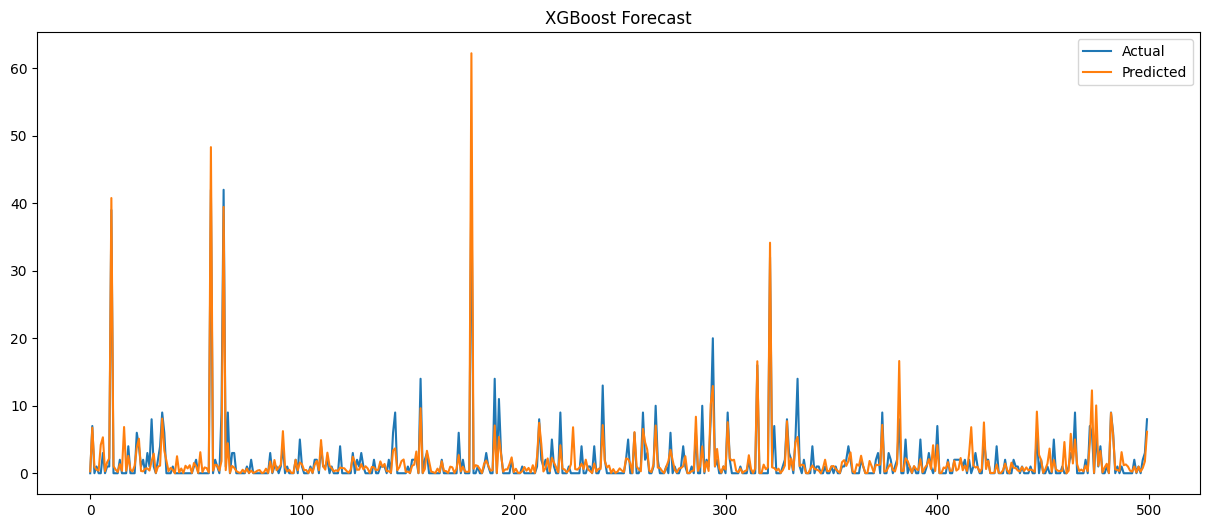

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.iloc[:500].values,
    label="Actual"
)

plt.plot(
    test_pred[:500],
    label="Predicted"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

**Feature Importance**

In [ ]:
importance=pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":xgb_model.feature_importances_

})

importance=importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
24,rolling_mean_7,0.411599
26,rolling_mean_14,0.209546
28,rolling_mean_28,0.105146
20,lag_1,0.036472
17,is_weekend,0.032564
21,lag_7,0.018846
7,wday,0.017559
22,lag_14,0.014011
23,lag_28,0.012653
16,quarter,0.011957


**Plot Feature Importance**

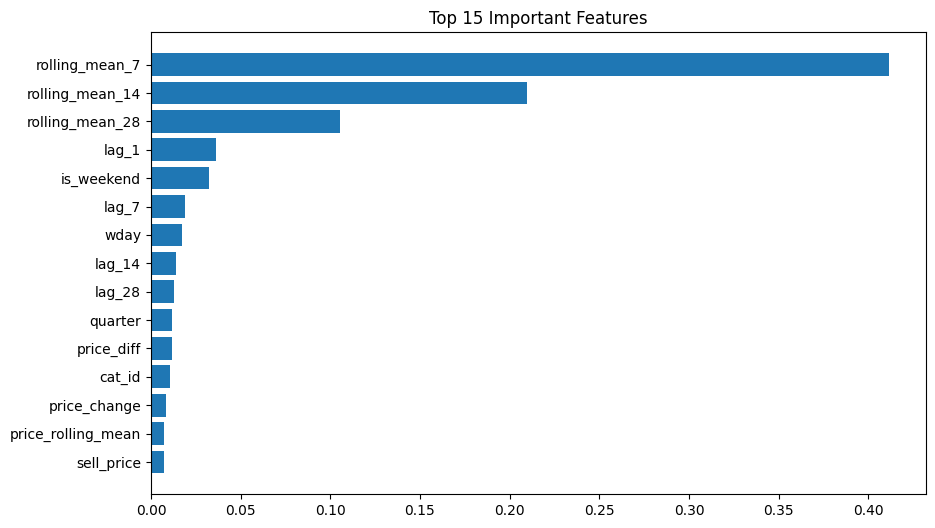

In [ ]:
top=importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

**Save Model**

In [ ]:
MODEL_PATH="/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/"

os.makedirs(MODEL_PATH,exist_ok=True)

joblib.dump(
    xgb_model,
    MODEL_PATH+"XGBoost.pkl"
)

['/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/XGBoost.pkl']

**Save Predictions**

In [ ]:
results=pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":test_pred

})

results.to_csv(
    RESULTS_PATH +"XGBoost_predictions.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


**Save Metrics**

In [ ]:
metrics_df = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

metrics_df.to_csv(
    RESULTS_PATH + "XGBoost_metrics.csv",
    index=False
)

print("✅ XGBoost metrics saved successfully!")
metrics_df

✅ XGBoost metrics saved successfully!


,Model,MAE,RMSE,MAPE,R2
0,XGBoost,1.015759,2.044782,57.551567,0.666737
